In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
#Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).

In [69]:
#Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).
df=pd.read_csv("C:\\Users\\ASUS\\Downloads\\assingment_1\\Basic stats - 1\\Basic stats - 1\\sales_data_with_discounts.csv")
df

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174


In [97]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include='number').columns.tolist()
print("Numerical cols:")
print(numerical_cols)

Numerical cols:
['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


In [101]:
#	Calculate the mean, median, mode, and standard deviation for these columns.
# Mean
print("Mean:\n", df[numerical_cols].mean())

# Median
print("\nMedian:\n", df[numerical_cols].median())

# Mode (first value in case of multiple modes)
print("\nMode:\n", df[numerical_cols].mode().iloc[0])

# Standard Deviation
print("\nStandard Deviation:\n", df[numerical_cols].std())

Mean:
 Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

Median:
 Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

Mode:
 Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64

Standard Deviation:
 Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64


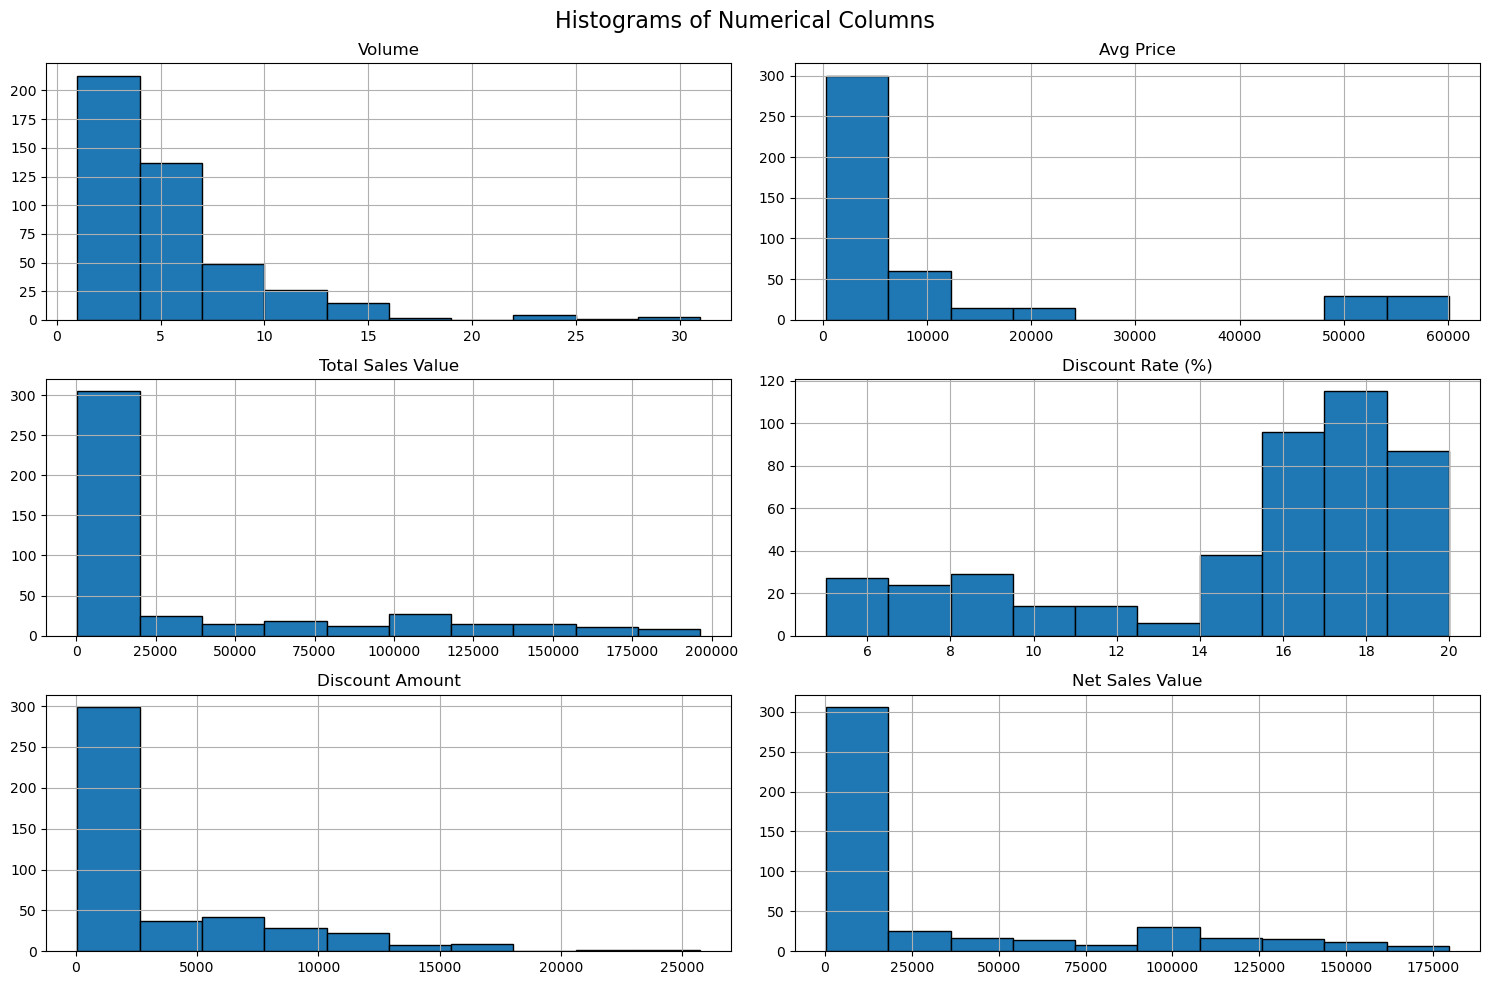

In [103]:
#	Plot histograms for each numerical column.
df[numerical_cols].hist(bins=10, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histograms of Numerical Columns', fontsize=16)
plt.tight_layout()
plt.show()

In [107]:
#Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.
# Calculate skewness
skewness = df[numerical_cols].skew()
# Display skewness
print("Skewness of Numerical Columns:")
print(skewness.round(2))

Skewness of Numerical Columns:
Volume               2.73
Avg Price            1.91
Total Sales Value    1.53
Discount Rate (%)   -1.06
Discount Amount      1.91
Net Sales Value      1.54
dtype: float64


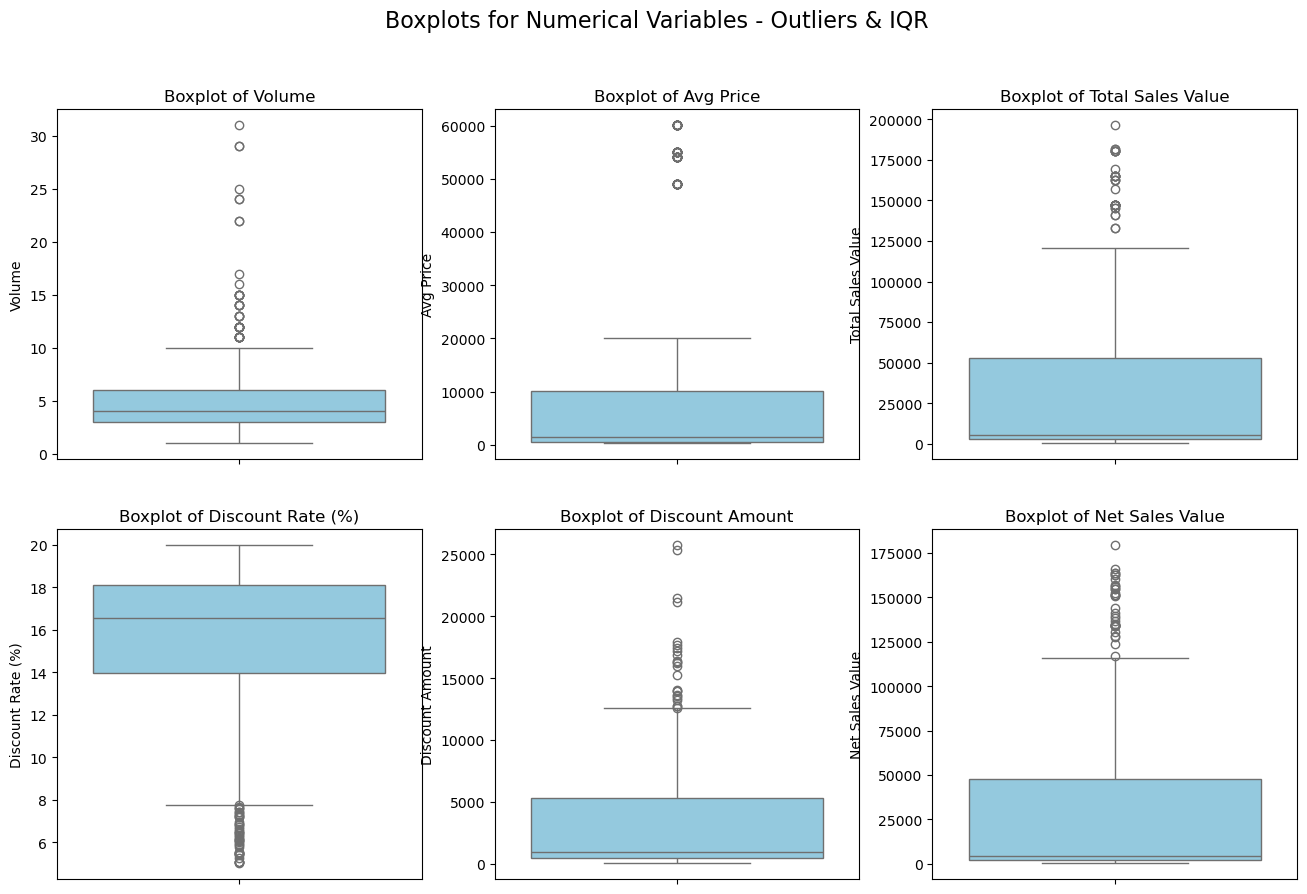

In [111]:
#Create boxplots for numerical variables to identify outliers and the interquartile range.
# Create individual boxplots for each numerical column
plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.xlabel('')
    plt.ylabel(col)
plt.suptitle('Boxplots for Numerical Variables - Outliers & IQR', fontsize=16)
plt.show()

In [115]:
#	Identify categorical columns in the dataset.
categorical_cols = df.select_dtypes(include='object')
print("categorical cols:")
print(categorical_cols.columns.tolist())

categorical cols:
['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


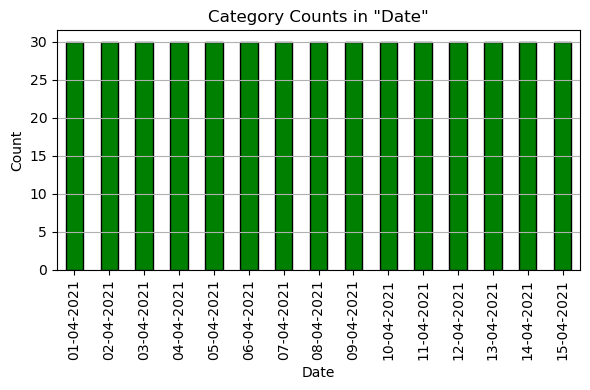

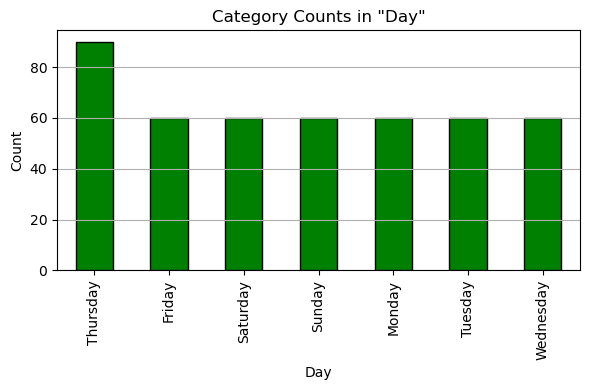

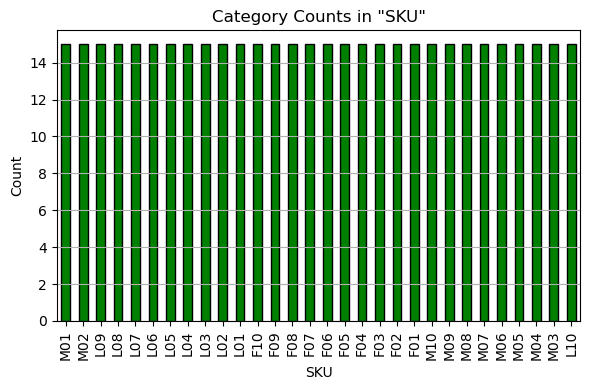

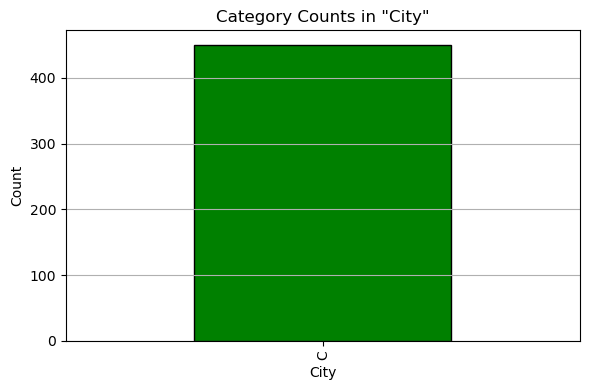

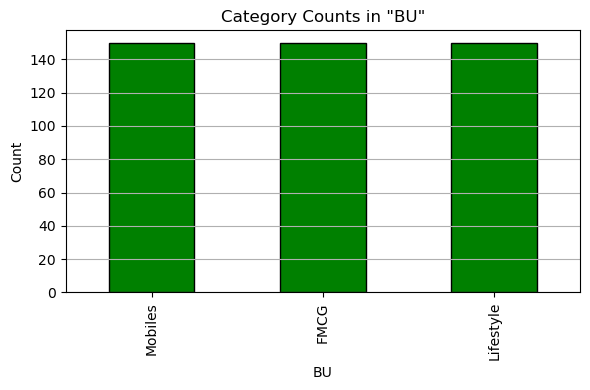

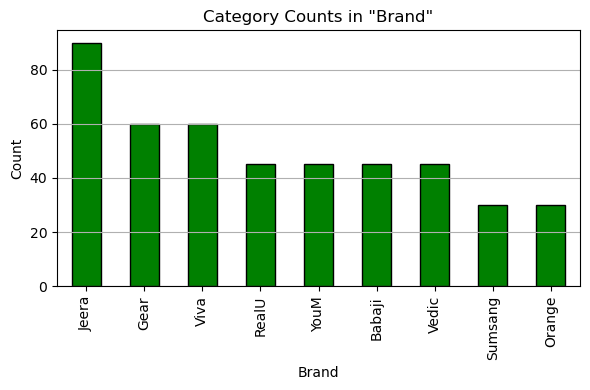

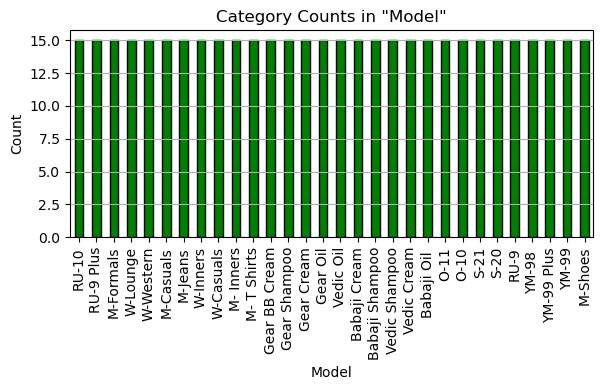

In [117]:
#	Create bar charts to visualize the frequency or count of each category.
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='bar', color='green', edgecolor='black')
    plt.title(f'Category Counts in "{col}"')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()

In [125]:
#	Standardize the numerical columns using the formula: z=x-mu/sigma
standardized_df = df.copy()
for col in numerical_cols:
    mean = df[col].mean()
    std = df[col].std()
    standardized_df[col] = (df[col] - mean) / std

# Check the result
print(standardized_df[numerical_cols].head())

# Optionally, check new means and stds
print("\nNew means:\n", standardized_df[numerical_cols].mean().round(2))
print("\nNew std deviations:\n", standardized_df[numerical_cols].std().round(2))

     Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0  2.347417   0.091072           2.922469          -0.829365         3.948422   
1  1.165831  -0.019548           1.329516          -0.851714         1.846958   
2  0.456880   0.312312           1.561038          -1.350129         1.621190   
3  0.220563   0.533552           1.717365          -1.947555         1.112568   
4 -0.488389  -0.130168          -0.188242           0.672990         0.227598   

   Net Sales Value  
0         2.801638  
1         1.269613  
2         1.543957  
3         1.763847  
4        -0.227342  

New means:
 Volume               0.0
Avg Price            0.0
Total Sales Value    0.0
Discount Rate (%)   -0.0
Discount Amount     -0.0
Net Sales Value      0.0
dtype: float64

New std deviations:
 Volume               1.0
Avg Price            1.0
Total Sales Value    1.0
Discount Rate (%)    1.0
Discount Amount      1.0
Net Sales Value      1.0
dtype: float64


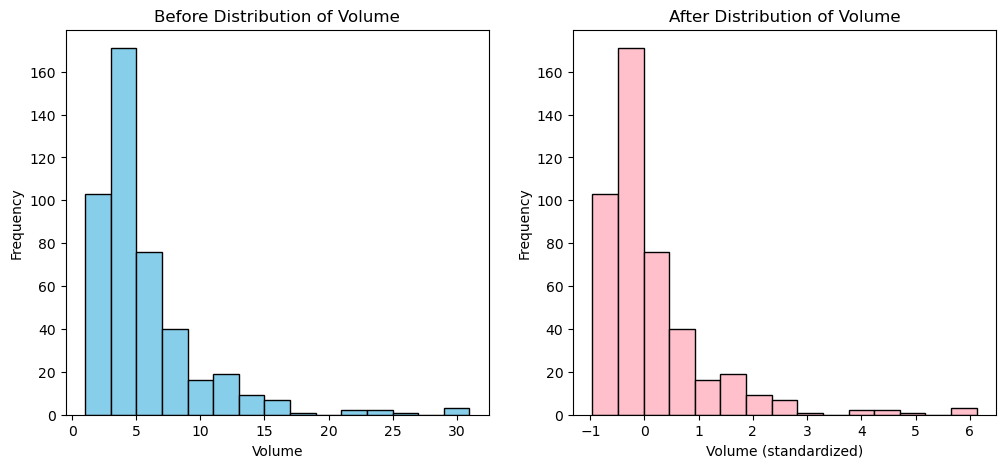

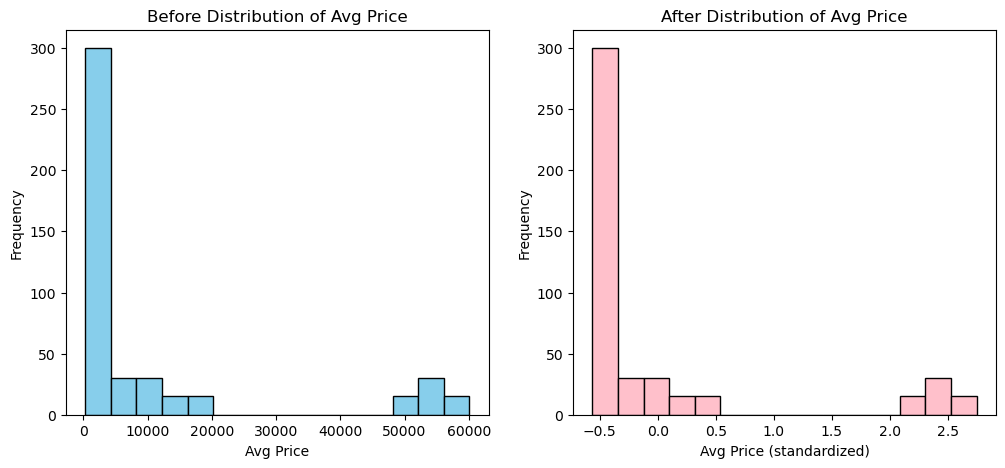

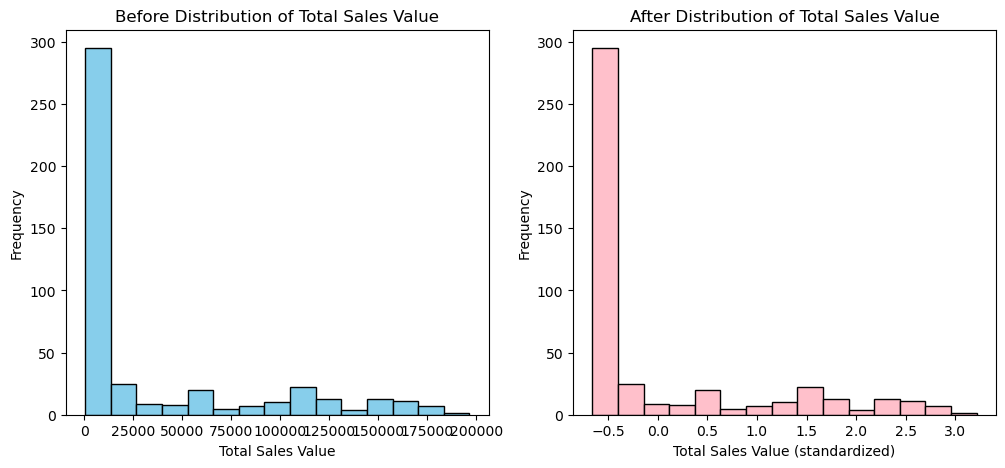

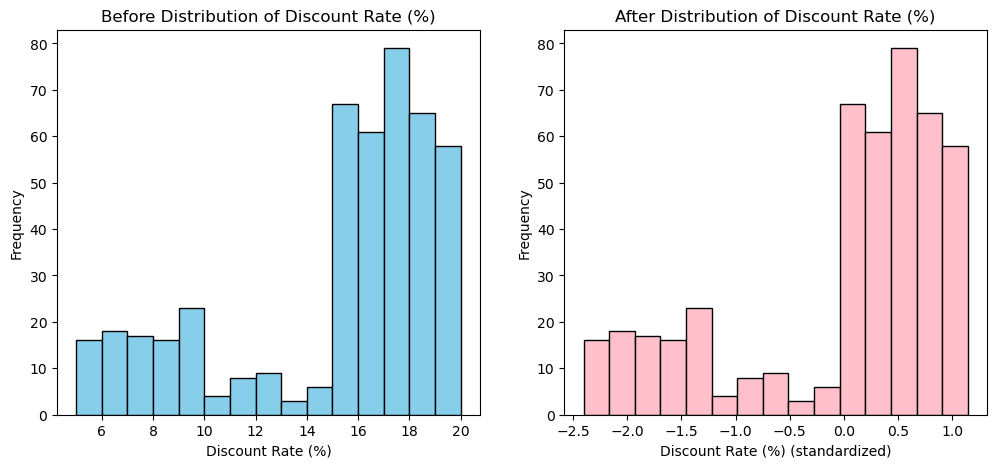

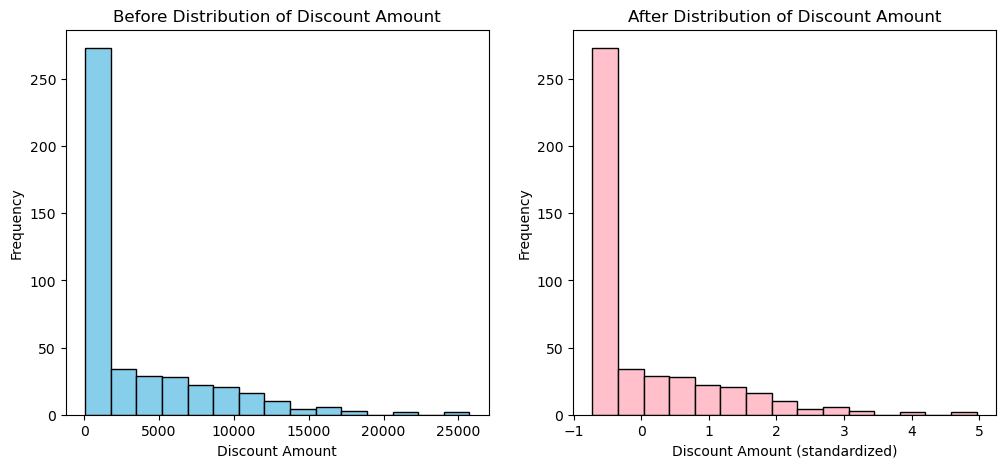

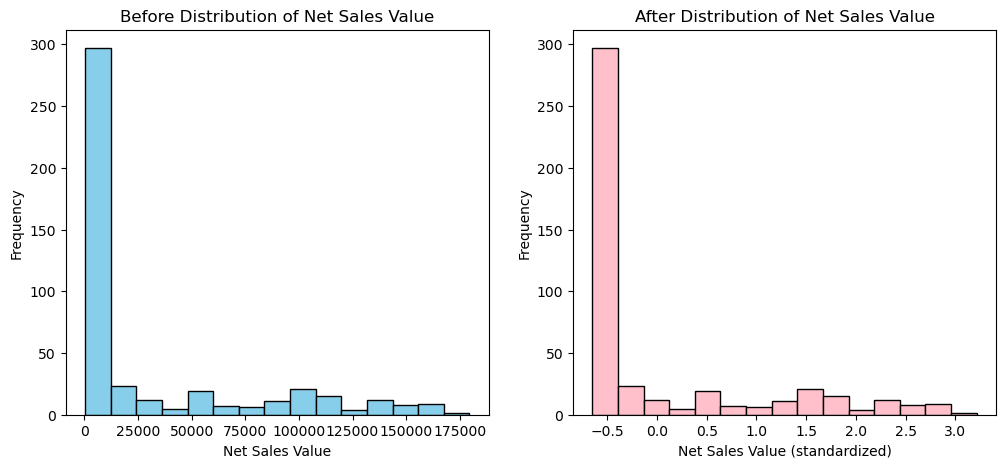

In [129]:
#Show before and after comparisons of the data distributions.
# Plot BEFORE and AFTER side by side
for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # Original
    plt.subplot(1, 2, 1)
    plt.hist(df[col], bins=15, color='skyblue', edgecolor='black')
    plt.title(f'Before Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Standardized
    plt.subplot(1, 2, 2)
    plt.hist(standardized_df[col], bins=15, color='pink', edgecolor='black')
    plt.title(f'After Distribution of {col}')
    plt.xlabel(f'{col} (standardized)')
    plt.ylabel('Frequency')

    plt.show()


In [131]:
#	Apply one-hot encoding to the categorical columns, creating binary (0 or 1) columns for each category.
df_encoded = pd.get_dummies(df, columns=categorical_cols.columns, drop_first=True)
print("Dataset after one-hot encoding:\n", df_encoded.head())


Dataset after one-hot encoding:
    Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      15      12100             181500          11.654820     21153.498820   
1      10      10100             101000          11.560498     11676.102961   
2       7      16100             112700           9.456886     10657.910157   
3       6      20100             120600           6.935385      8364.074702   
4       3       8100              24300          17.995663      4372.946230   

   Net Sales Value  Date_02-04-2021  Date_03-04-2021  Date_04-04-2021  \
0    160346.501180            False            False            False   
1     89323.897039            False            False            False   
2    102042.089843            False            False            False   
3    112235.925298            False            False            False   
4     19927.053770            False            False            False   

   Date_05-04-2021  ...  Model_Vedic Cream  Model_Ved

In [ ]:
#	Calculate the mean, median, mode, and standard deviation for these columns.
#	Provide a brief interpretation of these statistics.
Mean
Definition:
The mean is the average of a set of numbers.
Formula:
Mean=sum of all values/Total nuber of values
Example:
For values 10, 20, 30:
Mean=(10+20+30)/3=20

Median
Definition:
The median is the middle value in a dataset when it is sorted in order.
If the number of values is odd, it is the middle one.
If even, it is the average of the two middle values.
Example:
For values: 10, 20, 30  Median = 20
For values: 10, 20, 30, 40 Median = (20 + 30)/2 = 25

Mode
Definition:
The mode is the value that occurs most frequently in a dataset.
Example:
In the set: 5, 7, 7, 10  Mode = 7

Standard Deviation
Definition:
The standard deviation measures the spread or variability of the data  how far values are from the mean.    


#Discuss any findings, such as extreme values or unusual distributions.

-->Extreme values (Outliers):
All numerical columns show multiple outliers, confirmed by both the boxplots and the calculated outlier counts:
Avg Price (60 outliers) and Volume (44 outliers) stand out the most.
Even metrics like Discount Rate (%) have 45 outliers, despite smaller value ranges.
These outliers indicate that while most transactions are typical (small in size or value), some are unusually high, which could be large bulk orders or premium sales.

-->Skewness (Unusual Distributions):
Volume, Avg Price, Total Sales Value, Discount Amount, and Net Sales Value all show positive skewness (right-skewed).
The bulk of the data is concentrated at lower values, with a long tail of large values.
This is typical in sales data, where most customers buy small quantities or lower-priced items, and a few make large purchases.

Discount Rate (%) is left-skewed, with a skewness of -1.06.
Discounts tend to cluster more towards higher percentages, with fewer cases of very low discounts.
Possibly reflecting a marketing strategy where higher discounts are commonly offered.

-->Overall Insights:
The dataset clearly suggests a business model reliant on frequent small-to-moderate transactions, with occasional large, high-value sales that significantly influence totals.
The presence of many outliers, especially in price and sales value, means averages alone might not represent typical transactions well. Medians are more stable indicators here.

#Explain the concept of standardization (z-score normalization).
--> Standardization (Z-score normalization) : 
Standardization is a method used to scale numerical data so that different features with different units or scales can be compared or used together in analysis or machine learning. 
The formula for standardization is :  z= (x−mu)/sigma
where x is the original value, μ is the mean of the column, and σ is the standard deviation. After standardization, the transformed values have a mean of 0 and a standard deviation of 1. Most of the standardized data usually falls between -3 and +3 sigma (i.e., between -3 and +3 on the z-score scale). This range covers about 99.7% of the data if it follows a normal distribution. Standardization helps to prevent columns with larger scales from dominating the model or analysis.


#Discuss the need for converting categorical data into dummy variables (one-hot encoding).
What Is One-Hot Encoding?
One-Hot Encoding is a method to convert categorical variables into binary (0 or 1) columns — called dummy variables.
Why It’s Needed
Machine Learning Algorithms Need Numbers
Models like linear regression, SVM, decision trees, etc., canot interpret text. They need numerical values for computation.
Avoid Misleading Orders
Encoding categories as 1, 2, 3 (label encoding) introduces false ordinal relationships. One-hot encoding preserves neutrality
Improves Model Accuracy
Proper encoding ensures algorithms treat categories independently, improving model performance and fairness.
Essential for Distance-Based Models
Algorithms like KNN or K-Means rely on distance calculations — raw categorical data would break these.


#Summarize the key findings from the descriptive analytics and data visualizations.
Basic statistics gave insight into trends and spread in numerical data.
Histograms and boxplots helped visualize data distribution and detect outliers.
Categorical data was analyzed via bar charts.
#Reflect on the importance of data preprocessing steps like standardization and one-hot encoding in data analysis and machine learning.
Numerical features were standardized using z-score normalization.
Categorical variables were encoded using one-hot encoding for machine learning readiness.
    